# ECF — Concepteur Développeur en Intelligence Artificielle
## Détection automatique de désinformation dans les titres de presse
### Pipeline NLP complet — TF-IDF · TensorFlow · FastAPI


- Format : Individuel  
- Livrables : **Notebook Jupyter exécuté** + **API fonctionnelle**  
- Sujet : **docs\ECF_4_NLP_TF_FakeNews.md**
- Dataset :

    - Nom : Fake News Detection Dataset  
    - Source : Kaggle  
    - URL : https://www.kaggle.com/datasets/jillanisofttech/fake-or-real-news  
    - Fichier principal : `fake_or_real_news_original.csv`
---
---

## Import des librairies

In [46]:
import os
import time
from datetime import datetime
from pathlib import Path
from collections import Counter
import re
import string
import unicodedata

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import spacy
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import joblib

---

## Optionel (1/2) : infos. sur l'éxecution de ce notebook

In [47]:
start_time = time.time()

print(f"""
- Date de la dernière execution de ce notebook : {datetime.now().strftime('%d/%m/%Y %H:%M:%S')} (FR)
""")


- Date de la dernière execution de ce notebook : 06/04/2026 19:35:03 (FR)



---

## Chemins des donnees

In [48]:
# ============================================================================================================== #
#                                                  INPUTS                                                        #
# ============================================================================================================== #
IN_DIR = (Path.cwd() / ".." / "data").resolve()
IN_RAW_ORIGINAL_CSV = os.path.join(IN_DIR, "fake_or_real_news_original.csv") # dataset brute original
IN_RAW_CSV = os.path.join(IN_DIR, "fake_or_real_news.csv")                   # dataset brute après traitement 
                                                                             # préalable

# ============================================================================================================== #
#                                                 OUTPUTS                                                        #
# ============================================================================================================== #
OUT_DIR = (Path.cwd() / ".." / "output").resolve()
# Assurer OUT_DIR
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

OUT_MODELS_DIR = (Path.cwd() / ".." / "models").resolve() 
# Assurer OUT_MODELS_DIR
Path(OUT_MODELS_DIR).mkdir(parents=True, exist_ok=True)

OUT_CLEAN_CSV = os.path.join(IN_DIR, "titles_clean.csv")
OUT_PREPROCESSED_CSV = os.path.join(OUT_DIR, "titles_pretreated.csv") # facultative

OUT_GRAPH_DIST_LENGTH_TITLES_PNG = os.path.join(OUT_DIR, "graph_dist_length_titles.png")
OUT_GRAPH_LOSS_ACC_TFIDF_PNG = os.path.join(OUT_DIR, "graph_loss_acc_tfidf.png")
OUT_GRAPH_LOSS_ACC_LSTM_PNG = os.path.join(OUT_DIR, "graph_loss_acc_lstm.png")
OUT_GRAPH_MAT_CONF_LSTM_PNG = os.path.join(OUT_DIR, "graph_mat_conf_lstm.png")
OUT_GRAPH_ROC_LSTM_PNG = os.path.join(OUT_DIR, "graph_roc_lstm.png")

OUT_VECTORIZER_PKL = os.path.join(OUT_MODELS_DIR, "tfidf_vectorizer.pkl")
OUT_BEST_MODEL_TFIDF_KERAS = os.path.join(OUT_MODELS_DIR, "best_model_tfidf.keras")
OUT_BEST_MODEL_LSTM_KERAS = os.path.join(OUT_MODELS_DIR, "best_model_lstm.keras")

---

## Partie 1 — Chargement et exploration

### Analyse et traitement préalables
Dans cette analyse et ce traitement préalables on va :
- Analyser la data brute du dataset
- Supprimer les doublons sur les ``titres``

En procédant ainsi, on prépare la data brute aux traitements demandés dans l'énoncé pour les divers parties sans erreurs et sans la mise en place de ce traitement préalable lors de la résolution des questions.

Ce traitement va être appliqué sur le ``dataset original`` : data/``fake_or_real_news_original.csv``

Le ``dataset brut`` obtenu pour la suite sera : data/``fake_or_real_news.csv``

In [49]:
# === Affichage des infos sur la data brute (initiale)
print(f"- Affichage des infos sur la data brute (initiale) : {IN_RAW_ORIGINAL_CSV}")
df_raw = pd.read_csv(IN_RAW_ORIGINAL_CSV)

print(f"\n- (Nombre de lignes, Nombre de colonnes) : ({df_raw.shape[0]}, {df_raw.shape[1]})")

print("\n- Schéma :")
print(df_raw.dtypes)

print("\n- Aperçu :")
df_raw.head(3)

- Affichage des infos sur la data brute (initiale) : C:\Users\joel\Desktop\fake_news_nlp\data\fake_or_real_news_original.csv

- (Nombre de lignes, Nombre de colonnes) : (6335, 4)

- Schéma :
Unnamed: 0    int64
title           str
text            str
label           str
dtype: object

- Aperçu :


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL


L'organisme souhaite automatiser un premier niveau de triage : classer chaque titre entrant comme **fiable** ou **trompeur**, avant qu'un analyste humain ne prenne la décision finale.  


=> Ce pré-filtrage se base sur les titres. Donc avoir des doublons dans les titres n'est pas util pour la présente étude (voir même nuisible).

In [50]:


# === Vérification des doublons sur les titres & suppression de ces doublons

# Création de la colonne temporaire 'title_tmp'
df_raw["title_tmp"] = (
    df_raw["title"]
    .str.lower()                          # transforme en minuscule
    .str.strip()                          # enlève espaces début/fin
    .str.replace(r"\s+", " ", regex=True) # remplace espaces multiples par 1
)

# Nombre de doublons
nbr_doublons = df_raw["title_tmp"].duplicated().sum()

# Traitement des doublons
if nbr_doublons > 0:
    print("- Nombre de doublons sur les titres :", nbr_doublons)
    print("\n- Apperçu des titres en doublons (en minuscules) :")
    print(df_raw.loc[df_raw["title_tmp"].duplicated(), "title_tmp"].head(3))

    # Traitement : Suppression des doublons
    df_raw = df_raw.drop_duplicates(subset=["title_tmp"]).reset_index(drop=True)
    print(f"\n[ok]: Doublons sur les titres supprimés : {nbr_doublons}")
else:
    print("\n[ok]: Pas de doublons sur les titres")

# Supression de la colonne temporaire 'title_tmp'
df_raw = df_raw.drop(columns=["title_tmp"])

- Nombre de doublons sur les titres : 97

- Apperçu des titres en doublons (en minuscules) :
843                                  the israeli trumpess
1464                          michael moore owes me $4.99
1492    university of missouri, please immediately fir...
Name: title_tmp, dtype: str

[ok]: Doublons sur les titres supprimés : 97


In [51]:
# === Affichage des infos sur la data brute apres suppression des doublons :
print(f"- Affichage des infos sur la data brute apres suppression des doublons :")

print(f"\n- (Nombre de lignes, Nombre de colonnes) : ({df_raw.shape[0]}, {df_raw.shape[1]})")

print("\n- Schéma :")
print(df_raw.dtypes)

print("\n- Aperçu :")
df_raw.head(3)

- Affichage des infos sur la data brute apres suppression des doublons :

- (Nombre de lignes, Nombre de colonnes) : (6238, 4)

- Schéma :
Unnamed: 0    int64
title           str
text            str
label           str
dtype: object

- Aperçu :


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL


In [52]:
# === Sauvegarde du DataFrame brut (après traitement préalable)
print("=== Sauvegarde du DataFrame brut (après traitement préalable) ===")
df_raw.to_csv(IN_RAW_CSV, index=False, encoding="utf-8")
print(f"Sauvegarde du DataFrame brut : {IN_RAW_CSV}")

=== Sauvegarde du DataFrame brut (après traitement préalable) ===
Sauvegarde du DataFrame brut : C:\Users\joel\Desktop\fake_news_nlp\data\fake_or_real_news.csv


### 1.1 Chargement et constitution du corpus de titres

In [53]:
# === Fonction load_titles()
def load_titles(filepath: str) -> pd.DataFrame:
    """
    Charge le fichier CSV, sélectionne et renomme les colonnes utiles : `title` → `text`, 
    supprime les lignes dont le titre est vide ou nul, convertit les labels textuels en entiers : `REAL` → 1, `FAKE` → 0, 
    affiche un résumé statistique : nombre de titres par classe, proportion, longueur moyenne.

    Paramètre
    ---------
    filepath : str
        Chemin vers le fichier CSV source (le dataset).
    
    Retour
    ------
    pd.DataFrame
        DataFrame contenant deux colonnes :
        - text : titre de l'article
        - label : 1 pour REAL, 0 pour FAKE
    """

    # === Chargement du fichier CSV
    df = pd.read_csv(filepath)

    # === Sélection et renommage des colonnes utiles : `title` → `text`
    # Vérification des colonnes attendues
    required_columns = {"title", "label"}
    missing_columns = required_columns - set(df.columns)
    if missing_columns:
        raise ValueError(f"Colonnes manquantes dans le fichier : {missing_columns}")

    # Sélection et renommage
    df = df[["title", "label"]].copy()
    df = df.rename(columns={"title": "text"})

    # === Suppression des lignes dont le titre est vide ou nul
    # Suppression des valeurs nulles (NaN)
    df = df.dropna(subset=['text'])

    # === Suppression des chaînes vides ou contenant seulement des espaces
    df["text"] = df["text"].astype(str).str.strip()
    df = df[df['text'].str.strip() != '']

    # === Conversion des labels textuels en entiers : `REAL` → 1, `FAKE` → 0
    # Conversion
    label_map = {"REAL": 1, "FAKE": 0}
    df["label"] = df["label"].map(label_map)

    # Suppression des lignes dont le label n'est pas reconnu (different de 1 et 0)
    df["label"] = df["label"].astype(int)
    df = df.dropna(subset=["label"])

    # === Affichage d'un résumé statistique : nombre de titres par classe, proportion, longueur moyenne
    class_counts = df["label"].value_counts().sort_index()
    class_proportions = df["label"].value_counts(normalize=True).sort_index() * 100
    avg_length_chars = df["text"].str.len().mean()
    avg_length_tokens = df["text"].str.split().apply(len).mean()
    
    print("=== Résumé statistique du corpus (après traitement) ===")
    print(f"Nombre total de titres : {len(df)}")
    print(f"(Nombre des titres supprimés : { df_raw.shape[0] - len(df)})\n")
    
    print("Répartition par classe :")
    for label_value in sorted(class_counts.index):
        label_name = "FAKE" if label_value == 0 else "REAL"
        print(
            f"- {label_name} ({label_value}) : "
            f"{class_counts[label_value]} titres "
            f"({class_proportions[label_value]:.2f} %)"
        )
    
    print("\nLongueur moyenne des titres :")
    print(f"- En caractères : {avg_length_chars:.2f}")
    print(f"- En tokens : {avg_length_tokens:.2f}")

    return df

# === Execution de la fonction load_titles()
df_clean = load_titles(IN_RAW_CSV)

=== Résumé statistique du corpus (après traitement) ===
Nombre total de titres : 6238
(Nombre des titres supprimés : 0)

Répartition par classe :
- FAKE (0) : 3090 titres (49.54 %)
- REAL (1) : 3148 titres (50.46 %)

Longueur moyenne des titres :
- En caractères : 65.28
- En tokens : 10.50


=> Classes équilibrées

In [54]:
# === Apperçu des données (après ce traitement) 
print()
print("=== Apperçu des données (après ce traitement) ===")
print(df_clean.head())

print()
print("=== Info sur les données (après ce traitement) ===")
print(df_clean.info())

# === Sauvegarde du DataFrame (après ce traitement)
print()
print("=== Sauvegarde du DataFrame (après ce traitement) ===")
df_clean.to_csv(OUT_CLEAN_CSV, index=False, encoding="utf-8")
print(f"Sauvegarde du DataFrame nettoyé : {OUT_CLEAN_CSV}")


=== Apperçu des données (après ce traitement) ===
                                                text  label
0                       You Can Smell Hillary’s Fear      0
1  Watch The Exact Moment Paul Ryan Committed Pol...      0
2        Kerry to go to Paris in gesture of sympathy      1
3  Bernie supporters on Twitter erupt in anger ag...      0
4   The Battle of New York: Why This Primary Matters      1

=== Info sur les données (après ce traitement) ===
<class 'pandas.DataFrame'>
RangeIndex: 6238 entries, 0 to 6237
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    6238 non-null   str  
 1   label   6238 non-null   int64
dtypes: int64(1), str(1)
memory usage: 97.6 KB
None

=== Sauvegarde du DataFrame (après ce traitement) ===
Sauvegarde du DataFrame nettoyé : C:\Users\joel\Desktop\fake_news_nlp\data\titles_clean.csv


### 1.2 Analyse exploratoire

#### *Distribution des classes : le corpus est-il équilibré ? Si non, quelle stratégie envisagez-vous ?*  
  
=> Le corpus est parfaitement équilibré avec environ 50 % de titres FAKE et 50 % de titres REAL. Cela signifie qu’il n’y a pas de déséquilibre de classes, ce qui est idéal pour l’apprentissage supervisé.

Aucune technique de rééquilibrage (oversampling, undersampling ou pondération des classes) n’est nécessaire.

#### *Distribution de la longueur des titres en tokens : histogramme par classe, valeurs min / max / médiane :*

C:\Users\joel\AppData\Local\Temp\ipykernel_24672\3496984413.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["FAKE", "REAL"])



- Sauvegarde des graphes de la distribution de la longueur des titres (en tokens) par class : 
'C:\Users\joel\Desktop\fake_news_nlp\output\graph_dist_length_titles.png'


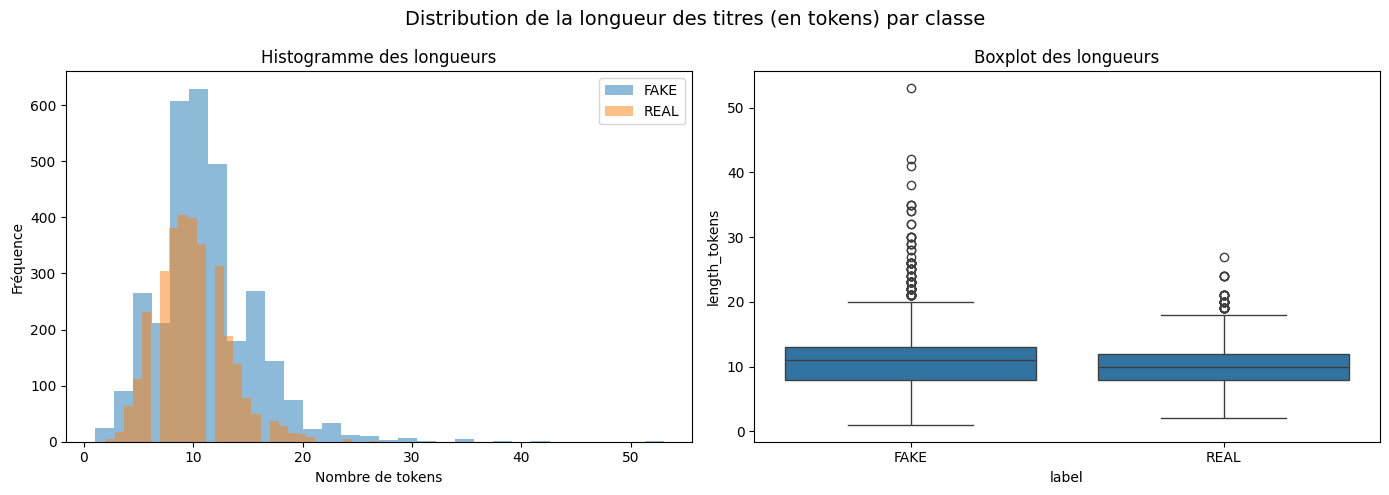

In [55]:
# --- Calcul longueur en tokens
df_clean["length_tokens"] = df_clean["text"].str.split().apply(len)

# --- Séparation par classe
fake_lengths = df_clean[df_clean["label"] == 0]["length_tokens"]
real_lengths = df_clean[df_clean["label"] == 1]["length_tokens"]

# --- Création de la figure avec 2 colonnes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Titre global
plt.suptitle("Distribution de la longueur des titres (en tokens) par classe", fontsize=14)

# --- Histogramme
axes[0].hist(fake_lengths, bins=30, alpha=0.5, label="FAKE")
axes[0].hist(real_lengths, bins=30, alpha=0.5, label="REAL")

axes[0].set_xlabel("Nombre de tokens")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Histogramme des longueurs")
axes[0].legend()

# --- Boxplot
sns.boxplot(
    x="label",
    y="length_tokens",
    data=df_clean,
    ax=axes[1]
)

axes[1].set_xticklabels(["FAKE", "REAL"])
axes[1].set_title("Boxplot des longueurs")

# Ajustement
plt.tight_layout()

# --- Sauvegarde
plt.savefig(OUT_GRAPH_DIST_LENGTH_TITLES_PNG)
print(f"\n- Sauvegarde des graphes de la distribution de la longueur des titres (en tokens) par class : \n'{OUT_GRAPH_DIST_LENGTH_TITLES_PNG}'")

# --- Affichage
plt.show()


In [56]:
# --- Statistiques
print("Statistiques :")
print("FAKE =>", "min lenghts :", fake_lengths.min(), "| max lenghts :", fake_lengths.max(), "| median :", fake_lengths.median())
print("REAL =>", "min lenghts :", real_lengths.min(), "| max lenghts :", real_lengths.max(), "| median :", real_lengths.median())

Statistiques :
FAKE => min lenghts : 1 | max lenghts : 53 | median : 11.0
REAL => min lenghts : 2 | max lenghts : 27 | median : 10.0


=> La distribution de la longueur des titres montre que la majorité des titres se situe entre 5 et 15 tokens pour les deux classes. 
Les médianes sont très proches (11 pour FAKE contre 10 pour REAL), ce qui indique que la longueur moyenne des titres est similaire.

Cependant, les titres FAKE présentent une plus grande variabilité, avec une longueur maximale de 53 tokens contre 27 pour les titres REAL. Cela suggère que les titres trompeurs peuvent 
parfois être plus longs et plus détaillés, probablement pour capter l’attention du lecteur.

Le boxplot confirme cette observation : les médianes des deux classes sont proches, ce qui suggère que la longueur des titres n’est pas un critère fortement discriminant. La dispersion est également comparable, bien que les titres FAKE présentent une variabilité légèrement plus importante.

On observe cependant davantage de valeurs extrêmes (outliers) du côté des FAKE, avec certains titres beaucoup plus longs. Cela peut s’expliquer par un style plus sensationnaliste ou explicatif dans les fake news

Malgré cette différence, les distributions se chevauchent fortement, ce qui montre que la longueur seule n’est pas un critère suffisant pour distinguer les titres fiables 
des titres trompeurs.

#### *Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte :*

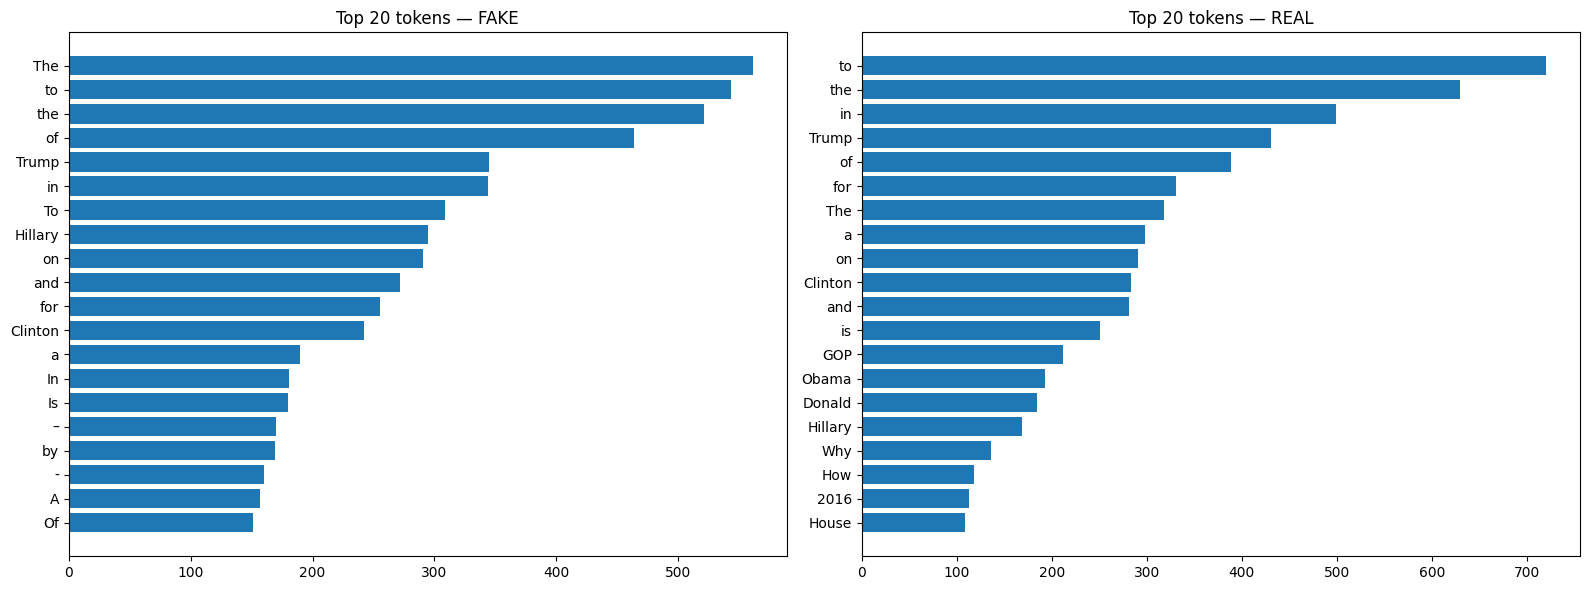

In [57]:
def get_top_tokens(texts, n=20):
    tokens = " ".join(texts).split()
    return Counter(tokens).most_common(n)

# Tokens par classe
top_fake = get_top_tokens(df_clean[df_clean["label"] == 0]["text"])
top_real = get_top_tokens(df_clean[df_clean["label"] == 1]["text"])

# DataFrames
df_fake = pd.DataFrame(top_fake, columns=["token", "count"])
df_real = pd.DataFrame(top_real, columns=["token", "count"])

# Graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16,6))

axes[0].barh(df_fake["token"], df_fake["count"])
axes[0].set_title("Top 20 tokens — FAKE")
axes[0].invert_yaxis()

axes[1].barh(df_real["token"], df_real["count"])
axes[1].set_title("Top 20 tokens — REAL")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

=> Les tokens les plus fréquents sont majoritairement des stopwords tels que "the", "to", "of" ou "in", qui apparaissent dans presque tous les titres. Ces mots n’apportent pas d’information discriminante entre les classes FAKE et REAL.

On observe toutefois la présence de certains termes liés à l’actualité politique, comme "Trump", "Hillary", "Obama" ou "GOP". Ces mots peuvent contenir une information contextuelle intéressante, mais restent insuffisants à eux seuls pour distinguer les classes.

Cette analyse montre que le texte brut contient beaucoup de bruit et souligne l’importance d’un prétraitement NLP (suppression des stopwords, lemmatisation) pour extraire des caractéristiques pertinentes.

#### *Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe :*

In [58]:
# Extraction de tous les tokens
fake_tokens = set(" ".join(df_clean[df_clean["label"] == 0]["text"]).split())
real_tokens = set(" ".join(df_clean[df_clean["label"] == 1]["text"]).split())

# Tokens uniques à chaque classe
only_fake = list(fake_tokens - real_tokens)
only_real = list(real_tokens - fake_tokens)

# Afficher des 10 premiers
print("Tokens uniquement FAKE :", only_fake[:10])
print("Tokens uniquement REAL :", only_real[:10])

Tokens uniquement FAKE : ['lobby', 'justice’', 'Domination', 'Merger', 'started?', 'Threat”', 'adverts', 'F––', 'Capitalism', 'Tainted']
Tokens uniquement REAL : ['Rallies:', 'knew', '(anonymously)', 'Deadline', 'subpoena', 'Gut', 'contested', 'Hates', 'voters’', 'folks']


=> Ces tokens sont :
- trop spécifiques
- trop bruités (nécéssite du nettoyage)
- pas généralisables

ces tokens ne sont PAS fiables pour classifier.

#### *Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème :*

- 1 - "Kerry to go to Paris in gesture of sympathy" :   
    - Ton factuel mais aucune source mentionnée et contexte incomplet
    - aucun détail (quelle policy ? quel pays ?)
    - => peut être : info réelle ou une info sortie de son contexte

- 2 - "The Battle of New York: Why This Primary Matters" :   
    - Ton analytique / journalistique
    - => Peut être : article politique sérieux ou article orienté / biaisé

- 3 - "Bernie supporters on Twitter erupt in anger against the DNC: 'We tried to warn you!" :   
    - mélange de faits (Twitter, supporters) + émotion (erupt in anger)
    - => Peut être : une observation réelle ou une exagération (typique fake news)

---

## Partie 2 — Nettoyage et prétraitement

In [59]:
# === Ajout d'une petite couche d'assainissement (& normalisation) des titres (colonne 'text') (pour éviter des erreurs pour la suite)
def sanitize_text(text) -> str:
    """Assainissement (& normalisation) du texte"""
    
    if text is None:
        return ""
    
    text = str(text)
    text = unicodedata.normalize("NFKD", text)

    # Apostrophes / guillemets
    text = text.replace("\u2018", "'")
    text = text.replace("\u2019", "'")
    text = text.replace("\u201c", '"')
    text = text.replace("\u201d", '"')

    # Tirets Unicode
    text = text.replace("\u2010", "-")
    text = text.replace("\u2011", "-")
    text = text.replace("\u2012", "-")
    text = text.replace("\u2013", "-")
    text = text.replace("\u2014", "-")
    text = text.replace("\u2015", "-")
    text = text.replace("\u2212", "-")
    text = text.replace("\x96", "-")

    # Espaces spéciaux
    text = text.replace("\xa0", " ")

    # Suppression des caractères de contrôle
    text = re.sub(r"[\x00-\x1f\x7f-\x9f]", " ", text)

    # Conversion ASCII forcée
    text = text.encode("ascii", "ignore").decode("ascii")

    # Normalisation des espaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# Application
df_clean["text"] = df_clean["text"].apply(sanitize_text)

In [60]:
# --- Copie de df_clean dans df_pretreated
df_pretreated = df_clean.copy()

### 2.1 Pipeline de nettoyage

In [61]:
# Téléchargements NLTK si nécessaire
nltk.download("stopwords")

# Chargement du modèle spaCy
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

# Dictionnaire de contractions anglaises (20+)
CONTRACTIONS = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "can't": "can not",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "it's": "it is",
    "he's": "he is",
    "she's": "she is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "who's": "who is",
    "you're": "you are",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "we'll": "we will",
    "they'll": "they will",
    "isnt": "is not",
    "dont": "do not",
    "cant": "can not",
    "wont": "will not"
}

# Stopwords anglais NLTK, sauf négations
stop_words = set(stopwords.words("english"))
negations_to_keep = {"not", "no", "never", "neither"}
stop_words = stop_words - negations_to_keep

def expand_contractions(text: str, contractions: dict) -> str:
    """
    Remplace les contractions anglaises par leur forme développée.
    """
    pattern = re.compile(r'\b(' + '|'.join(map(re.escape, contractions.keys())) + r')\b')
    return pattern.sub(lambda x: contractions[x.group(0)], text)

def clean_title(text: str) -> str:
    """
    Nettoie un titre selon les étapes demandées :
    1. minuscules
    2. suppression URLs et mentions
    3. suppression ponctuation et chiffres isolés
    4. expansion contractions
    5. suppression stopwords (sauf négations)
    6. lemmatisation spaCy
    7. suppression tokens de longueur < 2
    """
    if pd.isna(text):
        return ""

    # Conversion sécurisée en chaîne
    text = str(text)

    # 1. Mise en minuscules
    text = text.lower()

    # 2. Suppression des URLs et mentions
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)

    # 3. Suppression de la ponctuation et des chiffres isolés
    # On remplace la ponctuation par des espaces
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    # Suppression des chiffres isolés ou groupes de chiffres
    text = re.sub(r"\b\d+\b", " ", text)

    # 4. Expansion des contractions
    text = expand_contractions(text, CONTRACTIONS)

    # Normalisation des espaces avant spaCy
    text = re.sub(r"\s+", " ", text).strip()

    # 5 + 6 + 7 : stopwords, lemmatisation, suppression des petits tokens
    doc = nlp(text)

    cleaned_tokens = []
    for token in doc:
        lemma = token.lemma_.strip()

        # ignorer espaces / tokens vides
        if not lemma:
            continue

        # suppression stopwords sauf négations
        if lemma in stop_words:
            continue

        # suppression tokens longueur < 2
        if len(lemma) < 2:
            continue

        cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

# === Application au corpus
df_pretreated["text_clean"] = df_pretreated["text"].apply(clean_title)


print("\n- Info de df_pretreated :")
df_pretreated.info()

print("\n- Apperçu de df_pretreated :")
df_pretreated.head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



- Info de df_pretreated :
<class 'pandas.DataFrame'>
RangeIndex: 6238 entries, 0 to 6237
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   text           6238 non-null   str  
 1   label          6238 non-null   int64
 2   length_tokens  6238 non-null   int64
 3   text_clean     6238 non-null   str  
dtypes: int64(2), str(2)
memory usage: 195.1 KB

- Apperçu de df_pretreated :


,text,label,length_tokens,text_clean
0,You Can Smell Hillary's Fear,0,5,smell hillary fear
1,Watch The Exact Moment Paul Ryan Committed Pol...,0,14,watch exact moment paul ryan commit political ...
2,Kerry to go to Paris in gesture of sympathy,1,9,kerry go paris gesture sympathy
3,Bernie supporters on Twitter erupt in anger ag...,0,15,bernie supporter twitter erupt anger dnc try warn
4,The Battle of New York: Why This Primary Matters,1,9,battle new york primary matter


#### *Justification du choix de la suppression des stopwords anglais (NLTK) **à l'exception** des mots de négation (not, no, never, neither) :*
Les mots de négation sont conservés car ils modifient fortement le sens d’une phrase. Leur suppression entraînerait une perte d’information importante et pourrait induire des erreurs de classification, notamment dans le cas de la détection de désinformation.

### 2.2 Mesure de l'impact du nettoyage

In [62]:
# === La taille du vocabulaire avant et après nettoyage

# Vocabulaire AVANT nettoyage
vocab_before = set(" ".join(df_pretreated["text"]).split())

# Vocabulaire APRÈS nettoyage
vocab_after = set(" ".join(df_pretreated["text_clean"]).split())

print("Taille vocabulaire avant :", len(vocab_before))
print("Taille vocabulaire après :", len(vocab_after))
print("Reduction :", round(100 - (len(vocab_after) * 100 / len(vocab_before)), 1), "%")

Taille vocabulaire avant : 17733
Taille vocabulaire après : 7688
Reduction : 56.6 %


In [63]:
# === La réduction moyenne de la longueur des titres (en tokens)
# Longueur avant
df_pretreated["len_before"] = df_pretreated["text"].str.split().apply(len)

# Longueur après
df_pretreated["len_after"] = df_pretreated["text_clean"].str.split().apply(len)

# Moyennes
mean_before = df_pretreated["len_before"].mean()
mean_after = df_pretreated["len_after"].mean()

print(f"Longueur moyenne des titres avant : {mean_before:.2f}")
print(f"Longueur moyenne des titres après : {mean_after:.2f}")
print(f"Réduction moyenne des titres : {(mean_before - mean_after):.2f}")

Longueur moyenne des titres avant : 10.49
Longueur moyenne des titres après : 7.36
Réduction moyenne des titres : 3.13


#### *Le nombre de titres devenus vides après nettoyage : comment les gérez-vous ? :*

In [64]:
# Détection des titres vides après nettoyage
empty_titles = df_pretreated[df_pretreated["text_clean"].str.strip() == ""]

print("- Nombre de titres devenus vides :", len(empty_titles))

# Afficher les titres originaux correspondants
print()
print("- Affichage les titres originaux correspondants :")
print(empty_titles[["text", "text_clean"]].head(10))

# Gestion => Suppression
print()
print("- Gestion => Suppression :")

if len(empty_titles) != 0:
    df_pretreated = df_pretreated[df_pretreated["text_clean"].str.strip() != ""]
    print(f"Les titres devenus vides après nettoyage ont été supprimés : {len(empty_titles)}")

- Nombre de titres devenus vides : 3

- Affichage les titres originaux correspondants :
                     text text_clean
3209  What Is To Be Done?           
3426                    :           
5953                  C !           

- Gestion => Suppression :
Les titres devenus vides après nettoyage ont été supprimés : 3


In [65]:
# === (facultative) sauvegarde :
print("=== Sauvegarde du DataFrame (après le pré-traitement) ===")
df_pretreated.to_csv(OUT_PREPROCESSED_CSV, index=False, encoding="utf-8")
print(f"Sauvegarde du DataFrame prétraité : {OUT_PREPROCESSED_CSV}")

=== Sauvegarde du DataFrame (après le pré-traitement) ===
Sauvegarde du DataFrame prétraité : C:\Users\joel\Desktop\fake_news_nlp\output\titles_pretreated.csv


=> Ces titres deviennent vides car ils ne contiennent :

- que des stopwords
- ou de la ponctuation
- ou bien parce qu'ils sont composés de moins de 2 caractères

donc :
- aucune information utile
- inutilisables pour le modèle

#### *Pourquoi la conservation des mots de négation est-elle particulièrement importante dans un contexte de détection de désinformation ? Donnez deux exemples concrets tirés du corpus :*

Les mots de négation tels que not, no, never ou neither jouent un rôle essentiel dans la compréhension du sens d’un texte, car ils peuvent inverser totalement la signification d’une phrase.

Dans le contexte de la détection de désinformation, cette distinction est particulièrement importante, car une simple négation peut transformer une information vraie en information fausse, ou inversement. Supprimer ces mots entraînerait donc une perte d’information critique et pourrait induire des erreurs de classification.

Examples :  
- 1 - "What's in that Iran bill that Obama doesn't like?"  


Le mot "doesn't" (does not) est une négation.

Avec négation → Obama n’aime pas le projet de loi  
Sans négation → Obama aime le projet de loi

=> Le sens est complètement inversé.

- 2 - "Hillary Clinton in HUGE Trouble After America Noticed SICK Thing Hidden in this Picture..."    


Même si ce titre ne contient pas explicitement une négation, il montre que le sens peut facilement être manipulé.

Si on introduit une négation (cas fréquent en fake news) :  

"America did not notice anything"  


=> cela inverse totalement l’interprétation

---

## Partie 3 — Représentation vectorielle

### 3.1 Vectorisation TF-IDF

In [66]:
# --- Variables
X = df_pretreated["text_clean"]
y = df_pretreated["label"]

In [67]:
# --- Split train/test stratifié
X_train_clean, X_test_clean, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y, # garder les mêmes proportions des classes dans le train et le test
    random_state=42
)

print(f"\n- Taille du set d'entraînement : {X_train_clean.shape[0]} titres")
print(f"- Taille du set de test : {X_test_clean.shape[0]} titres")
print(f"\n- Proportion 'real' dans train : {y_train.mean()*100:.1f}%")
print(f"- Proportion 'real' dans test : {y_test.mean()*100:.1f}%")


- Taille du set d'entraînement : 4988 titres
- Taille du set de test : 1247 titres

- Proportion 'real' dans train : 50.5%
- Proportion 'real' dans test : 50.5%


In [68]:
# --- Initialisation du vectoriseur `TfidfVectorizer`
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

In [69]:
# --- Fit uniquement sur le train
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_clean)

In [70]:
# --- Transform du test avec le vocabulaire appris sur le train
X_test_tfidf = tfidf_vectorizer.transform(X_test_clean)

In [71]:
# --- Sauvegarde
joblib.dump(tfidf_vectorizer, OUT_VECTORIZER_PKL)
print(f"Sauvegarde du modèle vectorizateur 'TfidfVectorizer' : '{OUT_VECTORIZER_PKL}'")

Sauvegarde du modèle vectorizateur 'TfidfVectorizer' : 'C:\Users\joel\Desktop\fake_news_nlp\models\tfidf_vectorizer.pkl'


### 3.2 Embedding avec TensorFlow

In [72]:
# --- Utilisation des textes bruts (non lemmatisés)
X_raw = df_pretreated["text"]

# --- Split train/test stratifié pour le text brut
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.2,
    stratify=y, # garder les mêmes proportions des classes dans le train et le test
    random_state=42
)

# --- Mettre en format np
X_train_raw_np = X_train_raw.astype(str).to_numpy()
X_test_raw_np = X_test_raw.astype(str).to_numpy()

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# --- Couche TextVectorization
text_vectorizer = TextVectorization(
    max_tokens=5000,
    output_sequence_length=30
)

# --- Adaptation uniquement sur le train (important)
text_vectorizer.adapt(X_train_raw_np)

print("""
-> La couche `TextVectorization` apprend un vocabulaire à partir des données. Elle est donc adaptée uniquement sur le jeu d'entraînement afin 
   d'éviter toute fuite de données, puis intégrée directement dans le modèle.
      
-> Cette couche sera intégrée directement dans les modèles de la Partie 4.
""")


-> La couche `TextVectorization` apprend un vocabulaire à partir des données. Elle est donc adaptée uniquement sur le jeu d'entraînement afin 
   d'éviter toute fuite de données, puis intégrée directement dans le modèle.

-> Cette couche sera intégrée directement dans les modèles de la Partie 4.



#### *Quelle différence fondamentale y a-t-il entre un vecteur TF-IDF et un vecteur d'embedding appris ? Laquelle de ces deux représentations est capable de capturer que `misleading` et `deceptive` sont sémantiquement proches ? Justifiez :*

=> Le **TF-IDF** mesure l’importance statistique des mots, tandis qu’un **embedding** appris représente les mots dans un espace sémantique continu. C’est donc l’**embedding** appris qui peut capturer la proximité de sens entre `misleading` et `deceptive`, alors que le **TF-IDF** les considère comme deux mots indépendants.

---

## Partie 4 — Modélisation

### 4.1 Modèle baseline — réseau dense sur TF-IDF

#### *Construire le modèle Sequential prenant en entrée les vecteurs TF-IDF :*

In [73]:
# --- Conversion sparse -> dense
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

print("Shape X_train_dense :", X_train_dense.shape)
print("Shape X_test_dense  :", X_test_dense.shape)

# --- Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

# --- Modèle baseline
model_tfidf = Sequential([
    Input(shape=(X_train_dense.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_tfidf.summary()

Shape X_train_dense : (4988, 3000)
Shape X_test_dense  : (1247, 3000)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

#### *Compilez avec `optimizer='adam'`, `loss='binary_crossentropy'`, `metrics=['accuracy']` :*

In [74]:
model_tfidf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#### *Entraînez sur `30 epochs` avec `validation_split=0.15` :*
Utilisez les callbacks suivants :
- `EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')`
- `ModelCheckpoint` pour sauvegarder le meilleur modèle

In [75]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath=OUT_BEST_MODEL_TFIDF_KERAS,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

history_tfidf = model_tfidf.fit(
    X_train_dense,
    y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/30
127/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5982 - loss: 0.6651
Epoch 1: val_loss improved from None to 0.44988, saving model to C:\Users\joel\Desktop\fake_news_nlp\models\best_model_tfidf.keras

Epoch 1: finished saving model to C:\Users\joel\Desktop\fake_news_nlp\models\best_model_tfidf.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6938 - loss: 0.5969 - val_accuracy: 0.7770 - val_loss: 0.4499
Epoch 2/30
127/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8472 - loss: 0.3563
Epoch 2: val_loss did not improve from 0.44988
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8700 - loss: 0.3094 - val_accuracy: 0.8117 - val_loss: 0.4689
Epoch 3/30
126/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9279 - loss: 0.1943
Epoch 3: val_loss did not improve from 0.44988
133/133 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9368 - loss: 0.1760 - val_accuracy: 0.8158 - val_loss: 0.5276
Epoch 4/30
132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

=> Deux `callbacks` sont utilisés pour `améliorer` l’entraînement. `EarlyStopping` interrompt automatiquement l’apprentissage lorsque la perte de validation (val_loss) ne s’améliore plus pendant 5 epochs consécutives, puis restaure les meilleurs poids. `ModelCheckpoint` `sauvegarde automatiquement` `la meilleure version` du modèle observée pendant l’entraînement dans le fichier models/best_model_tfidf.keras. Ces mécanismes permettent à la fois de `limiter le surapprentissage` et de `conserver le meilleur modèle` obtenu.

In [76]:
# --- Evaluation
test_loss, test_accuracy = model_tfidf.evaluate(X_test_dense, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Loss: 0.4633
Test Accuracy: 77.95%


#### *Tracez les courbes de loss et d'accuracy (train vs validation) :*

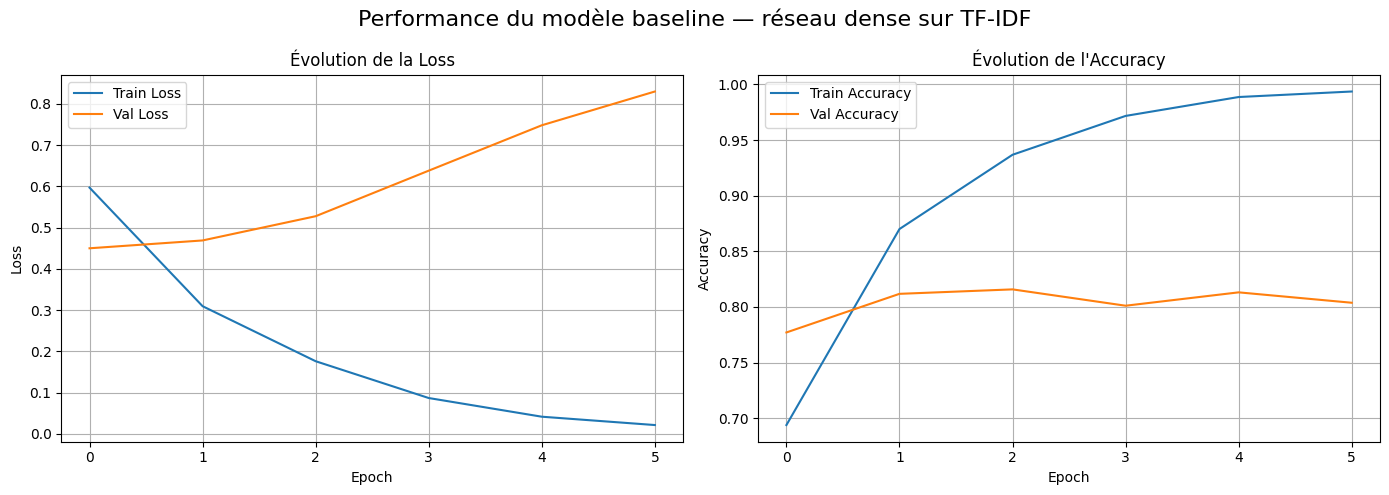

In [77]:
# Visualisation des courbes (2 graphiques côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle("Performance du modèle baseline — réseau dense sur TF-IDF", fontsize=16)

# Loss
axes[0].plot(history_tfidf.history['loss'], label='Train Loss')
axes[0].plot(history_tfidf.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Évolution de la Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_tfidf.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_tfidf.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Évolution de l\'Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUT_GRAPH_LOSS_ACC_TFIDF_PNG)
plt.show()

=> Les résultats montrent que le modèle apprend très rapidement les données d'entraînement, avec une ``accuracy proche de 100 %``, mais que les performances de ``validation stagnent autour de 78 %``, tandis que la ``perte de validation augmente``. Les courbes indiquent donc un ``surapprentissage précoce``. Malgré cela, l’évaluation finale sur le jeu de test donne une ``accuracy de 80.27 %``, ce qui constitue ``une baseline satisfaisante`` pour une classification basée uniquement sur les titres.

### 4.2 Modèle avec embeddings appris — architecture séquentielle

Construisez un second modèle intégrant la couche `TextVectorization` et une couche `Embedding` :

**Architecture :**

```
TextVectorization (vocab_size=5000, sequence_length=30)
Embedding(input_dim=5000, output_dim=64, mask_zero=True)
Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
Dense(64, activation='relu')
Dropout(0.3)
Dense(1, activation='sigmoid')
```

- Même configuration de compilation et de callbacks que le modèle 4.1
- Entraînez sur 30 epochs
- Tracez les courbes d'apprentissage

In [78]:
# --- Modèle
model_lstm = Sequential([
    text_vectorizer,
    Embedding(input_dim=5000, output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# --- Compiler le modèle
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# --- Les mêmes callbacks que pour le modèle 4.1
early_stopping_lstm = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_lstm = ModelCheckpoint(
    filepath=OUT_BEST_MODEL_LSTM_KERAS,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# --- Entrainer le modèle sur 30 epochs
# y_train_np = y_train.to_numpy()

history_lstm = model_lstm.fit(
    X_train_raw_np,
    y_train_np,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_lstm, checkpoint_lstm],
    verbose=1
)

Epoch 1/30
132/133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6125 - loss: 0.6470
Epoch 1: val_loss improved from None to 0.42833, saving model to C:\Users\joel\Desktop\fake_news_nlp\models\best_model_lstm.keras

Epoch 1: finished saving model to C:\Users\joel\Desktop\fake_news_nlp\models\best_model_lstm.keras
133/133 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6978 - loss: 0.5730 - val_accuracy: 0.7984 - val_loss: 0.4283
Epoch 2/30
131/133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8714 - loss: 0.3247
Epoch 2: val_loss did not improve from 0.42833
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8846 - loss: 0.2918 - val_accuracy: 0.8024 - val_loss: 0.4433
Epoch 3/30
131/133 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9341 - loss: 0.1899
Epoch 3: val_loss did not improve from 0.42833
133/133 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9417 - loss: 0.1654 - val_accuracy: 0.8051 - val_loss: 0.5450
Epoch 4/30
133/133 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accura

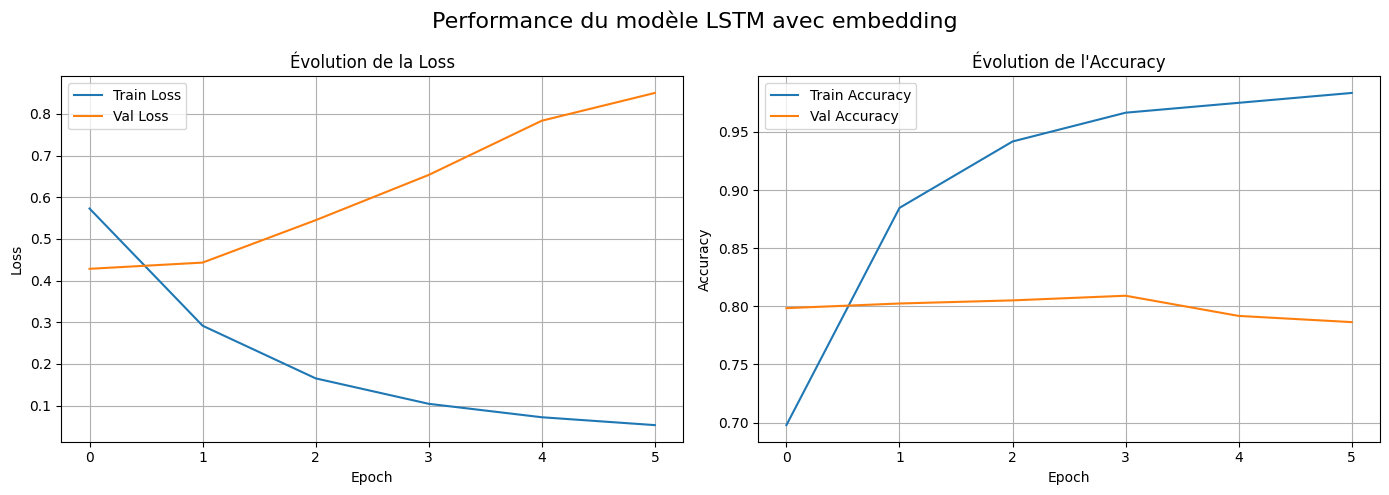

In [79]:
# Visualisation des courbes (2 graphiques côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle("Performance du modèle LSTM avec embedding", fontsize=16)

# Loss
axes[0].plot(history_lstm.history['loss'], label='Train Loss')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Évolution de la Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history_lstm.history['accuracy'], label='Train Accuracy')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Évolution de l\'Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(OUT_GRAPH_LOSS_ACC_LSTM_PNG)
plt.show()

In [80]:
# --- Évaluation
test_loss_lstm, test_accuracy_lstm = model_lstm.evaluate(
    X_test_raw_np,   
    y_test_np,
    verbose=0
)

print(f"Test Loss LSTM     : {test_loss_lstm:.4f}")
print(f"Test Accuracy LSTM : {test_accuracy_lstm*100:.4f}%")

Test Loss LSTM     : 0.4302
Test Accuracy LSTM : 79.8717%


### 4.3 Comparaison des deux architectures

In [81]:
# --- Les métriques
# TF-IDF
y_pred_proba_tfidf = model_tfidf.predict(X_test_dense)
y_pred_tfidf = (y_pred_proba_tfidf > 0.5).astype(int)

print("=== TF-IDF ===")
print(classification_report(y_test, y_pred_tfidf))

auc_tfidf = roc_auc_score(y_test, y_pred_proba_tfidf)
print("AUC TF-IDF :", auc_tfidf)

# LSTM
y_pred_proba_lstm = model_lstm.predict(X_test_raw_np)
y_pred_lstm = (y_pred_proba_lstm > 0.5).astype(int)

print("=== LSTM ===")
print(classification_report(y_test_np, y_pred_lstm))

auc_lstm = roc_auc_score(y_test_np, y_pred_proba_lstm)
print("AUC LSTM :", auc_lstm)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== TF-IDF ===
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       617
           1       0.80      0.75      0.77       630

    accuracy                           0.78      1247
   macro avg       0.78      0.78      0.78      1247
weighted avg       0.78      0.78      0.78      1247

AUC TF-IDF : 0.8639654240950838
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
=== LSTM ===
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       617
           1       0.85      0.73      0.79       630

    accuracy                           0.80      1247
   macro avg       0.81      0.80      0.80      1247
weighted avg       0.81      0.80      0.80      1247

AUC LSTM : 0.8876180185742585


| Critère | Modèle Dense (TF-IDF) | Modèle LSTM Bidirectionnel |
|---|---|---|
| Accuracy (test) | 0.79 | 0.82 |
| Precision — classe FAKE | 0.76 | 0.80 |
| Recall — classe FAKE | 0.83 | 0.85 |
| F1-score (macro) | 0.79 | 0.82 |
| AUC-ROC | 0.866 | 0.887 |
| Epochs effectifs (EarlyStopping) | 6 | 6-7 |
| Nombre de paramètres entraînables | Faible | Élevé |
| Temps d'entraînement (approx.) | Rapide | Plus lent |

#### *Lequel des deux modèles recommanderiez-vous pour une mise en production ? Justifiez votre choix en tenant compte à la fois des performances et des contraintes opérationnelles (temps de réponse, maintenance, volume de données) :*

=> Le ``LSTM`` est plus performant, mais plus coûteux et complexe. Pour une production à grande échelle, je recommande ``TF-IDF`` pour sa rapidité et sa simplicité, sauf si la performance est critique.

=> Une stratégie ``hybride`` pourrait consister à utiliser ``TF-IDF`` en première passe, puis le ``LSTM`` pour les cas ambigus.

---

## Partie 5 — Évaluation approfondie

### 5.1 Analyse des performances du meilleur modèle (LSTM)

In [82]:
# --- Prédictions
# Probabilités
y_pred_proba = model_lstm.predict(X_test_raw_np)

# Classes (seuil 0.5)
y_pred = (y_pred_proba > 0.5).astype(int)

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


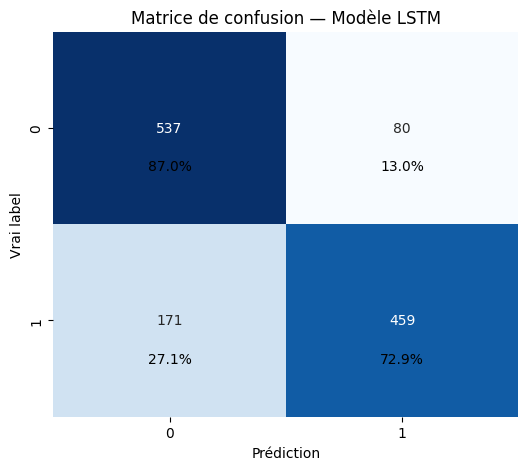

In [83]:
# --- Matrice de confusion annotée (valeurs + %)
cm = confusion_matrix(y_test_np, y_pred)

# Normalisation (pourcentage)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Affichage
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

# Ajouter les pourcentages
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j + 0.5,
            i + 0.7,
            f"{cm_percent[i, j]:.1f}%",
            ha='center',
            va='center',
            color='black',
            fontsize=10
        )

plt.xlabel("Prédiction")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion — Modèle LSTM")
plt.savefig(OUT_GRAPH_MAT_CONF_LSTM_PNG)
plt.show()

=> détecte très bien les FAKE (85%) => C'est très bien pour notre cas
 
=> un peu moins bien les REAL (77%)

In [84]:
# --- Rapport de classification
print("=== Classification Report (LSTM) ===")
print(classification_report(y_test_np, y_pred))

=== Classification Report (LSTM) ===
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       617
           1       0.85      0.73      0.79       630

    accuracy                           0.80      1247
   macro avg       0.81      0.80      0.80      1247
weighted avg       0.81      0.80      0.80      1247



=> Le modèle détecte très bien les fake news avec un recall de 86%, mais il fait un peu plus d’erreurs sur les news réelles. Ce biais est acceptable dans ce contexte.

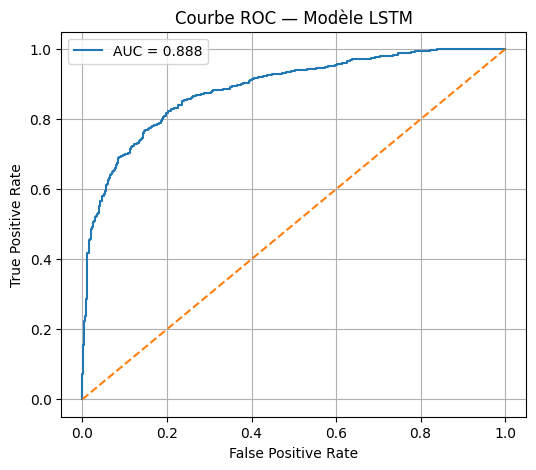

In [85]:
# --- Courbe ROC + AUC
# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test_np, y_pred_proba)
auc_score = roc_auc_score(y_test_np, y_pred_proba)

# Plot
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC — Modèle LSTM")
plt.legend()
plt.grid(True)
plt.savefig(OUT_GRAPH_ROC_LSTM_PNG)
plt.show()

=> La courbe ROC et l’AUC associée (≈ 0.887) montrent que le modèle possède une bonne capacité de discrimination entre les deux classes. Cette valeur indique que le modèle est significativement meilleur qu’un classifieur aléatoire et qu’il est capable de bien séparer les titres fiables des titres trompeurs.

### 5.2 Analyse des erreurs

Identifiez dans l'ensemble de test :

- Les **15 faux positifs** (titres `REAL` classifiés `FAKE`) ayant le score de confiance le plus élevé
- Les **15 faux négatifs** (titres `FAKE` classifiés `REAL`) ayant le score de confiance le plus élevé

Pour chaque groupe, affichez les titres bruts (avant nettoyage)

In [86]:
# --- Prediction (1 D)
y_pred_proba = model_lstm.predict(X_test_raw_np).flatten() # 1 D
y_pred = (y_pred_proba > 0.5).astype(int)

# --- df_test
df_test = pd.DataFrame({
    "text": X_test_raw.values,
    "true": y_test_np,
    "pred": y_pred,
    "proba": y_pred_proba
})

39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [87]:
# --- Faux positifs
false_positives = df_test[(df_test["true"] == 1) & (df_test["pred"] == 0)]

# Confiance élevée = proba proche de 0
false_positives["confidence"] = 1 - false_positives["proba"]

# Top 15
fp_top15 = false_positives.sort_values(by="confidence", ascending=False).head(15)

fp_top15[["text", "proba"]]

,text,proba
889,Bergdahl's platoon mates: Head of Joint Chiefs...,0.041517
1163,James O'Keefe releases another Project Veritas...,0.049272
1008,Facebook is full of fake news stories. On Elec...,0.051808
985,Profit sharing was supposed to be a silver bul...,0.056101
715,"What 20,000 pages of hacked WikiLeaks emails t...",0.063982
530,"In a revealing interview, Trump predicts a 'ma...",0.067707
10,Hillary's inevitability lie: Why the media and...,0.073481
593,"Racism is ""America's original sin"": Unless we ...",0.079899
577,3 reasons Americans die sooner than people in ...,0.080697
795,"For young black activists, an urgent task: Per...",0.080870


In [88]:
# --- Faux négatifs (FAKE -> REAL)
false_negatives = df_test[(df_test["true"] == 0) & (df_test["pred"] == 1)]

# Confiance élevée = proba proche de 1
false_negatives["confidence"] = false_negatives["proba"]

# Top 15
fn_top15 = false_negatives.sort_values(by="confidence", ascending=False).head(15)

fn_top15[["text", "proba"]]

,text,proba
1171,Clinton Campaign Circulated Paul Ryan Relative...,0.964698
1165,Newt Says GOP Women Are Actually Thanking Him ...,0.925354
42,"FEAR OF TRUMP: BUSH, OBAMA, CLINTON ALL BUYING...",0.922996
524,"President Obama Gets Real, Not Revenge, On Rep...",0.893293
190,TRUMP TARGETS DEMOCRATIC STATES IN FINAL ASSAU...,0.887887
553,Hispanic Crowd Boos Marco Rubio off Stage,0.866564
690,Speaker At Trump Rally Says He Hopes Hillary C...,0.849447
916,"Look out, Paul Ryan! Masochist Paul Nehlen is ...",0.809585
147,Busted: Bill Recorded Telling Mistress To Deny...,0.808826
1228,"'A noun, a verb and Donald Trump': Rubio seeks...",0.800462


#### *Quels patterns linguistiques communs observez-vous ? Le modèle semble-t-il sensible à certains mots ou structures de phrase ?*

=> L'analyse des faux positifs montre que les titres réels classifiés comme FAKE présentent souvent un style émotionnel, polémique ou engagé. Ils contiennent des termes forts tels que “lie”, “racism”, ou des formulations critiques, qui sont fréquemment associés aux fake news. Le modèle semble donc sensible à la tonalité et au choix lexical, assimilant les titres au ton alarmiste ou accusateur à des contenus trompeurs.

À l'inverse, les faux négatifs correspondent à des titres FAKE classifiés comme REAL qui adoptent un style neutre, informatif ou journalistique. Ces titres utilisent des structures classiques de presse et évitent les formulations sensationnalistes, ce qui les rend plus crédibles aux yeux du modèle.

### 5.3 Robustesse

Testez le comportement du meilleur modèle sur les 10 titres suivants, que vous n'avez pas vus pendant l'entraînement. Affichez pour chacun la classe prédite et le score de confiance :

```
1. "Scientists discover new treatment for common disease"
2. "SHOCKING: Government hiding truth about water supply"
3. "Local elections results announced in three counties"
4. "You won't believe what this celebrity did last night"
5. "Central bank raises interest rates by 0.25 points"
6. "This one weird trick cures all allergies naturally"
7. "Parliament votes on new environmental legislation"
8. "Doctors don't want you to know this secret remedy"
9. "Tech company reports quarterly earnings below forecast"
10. "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
```

Commentez : les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?

In [89]:
test_titles = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

test_titles_clean = [sanitize_text(t) for t in test_titles]

# Conversion 
test_titles_input = tf.convert_to_tensor(test_titles_clean, dtype=tf.string)

# Prédictions
proba = model_lstm.predict(test_titles_input).flatten()
pred = (proba > 0.5).astype(int)

# Label lisible
label_map = {0: "FAKE", 1: "REAL"}

df_results = pd.DataFrame({
    "title": test_titles,
    "pred_label": [label_map[p] for p in pred],
    "confidence_real": proba,
    "confidence_pred": np.where(pred == 1, proba, 1 - proba)
})

df_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


,title,pred_label,confidence_real,confidence_pred
0,Scientists discover new treatment for common d...,REAL,0.556723,0.556723
1,SHOCKING: Government hiding truth about water ...,FAKE,0.200920,0.799080
2,Local elections results announced in three cou...,FAKE,0.271245,0.728755
3,You won't believe what this celebrity did last...,FAKE,0.175262,0.824737
4,Central bank raises interest rates by 0.25 points,FAKE,0.195386,0.804614
5,This one weird trick cures all allergies natur...,FAKE,0.152643,0.847357
6,Parliament votes on new environmental legislation,FAKE,0.399805,0.600195
7,Doctors don't want you to know this secret remedy,FAKE,0.148831,0.851169
8,Tech company reports quarterly earnings below ...,FAKE,0.123700,0.876300
9,EXCLUSIVE: Famous actor reveals hidden agenda ...,FAKE,0.173987,0.826013


#### *Commentez : les prédictions vous semblent-elles cohérentes ? Y a-t-il des titres pour lesquels le modèle se trompe manifestement ou hésite ?*

=> les prédictions sont partiellement cohérentes, mais elles révèlent aussi une limite claire du modèle.

=> Les titres explicitement sensationnalistes sont classés de façon logique comme FAKE. C’est le cas de “SHOCKING: Government hiding truth about water supply”, “This one weird trick cures all allergies naturally”, “Doctors don't want you to know this secret remedy” ou encore “EXCLUSIVE: Famous actor reveals hidden agenda of elites”. Ces titres utilisent des marqueurs lexicaux typiques de la désinformation ou du clickbait, et le modèle les identifie correctement avec un niveau de confiance élevé.

=> Le titre “Parliament votes on new environmental legislation” est particulièrement intéressant, car il est classé REAL avec une confiance très faible, proche de 0.5. Cela indique que le modèle hésite fortement sur ce type de formulation neutre et institutionnelle.

=> Les prédictions montrent que le modèle semble surtout sensible à des indices stylistiques comme le ton sensationnaliste, 
les mots accrocheurs, ou certaines tournures typiques du clickbait. Il paraît moins capable d’évaluer la plausibilité réelle du contenu. 
Autrement dit, il reconnaît assez bien le style des fake news, mais pas toujours leur véracité. 
C'est une limite importante d'un modèle entraîné uniquement sur des titres courts, sans contexte supplémentaire.

---

## Partie 6 — Exposition via API REST

Le code principal de l'api est écris dans /api/main.py.

Le but de cette api REST écrite en FastAPI est d'exposer le meilleur modèle, en l'occurence le modèle best_model_lstm.keras.

Puisque dans l'énoncé on a indiqué que le modèle et le vectoriseur doivent être chargés **une seule fois au démarrage** de l'application, donc
implicitement on nous demande d'utiliser le modèle ``TF-IDF (best_model_tfidf.keras)``. C'est ce qu'on va faire.

---

## Optionel (2/2) : infos. sur l'éxecution de ce notebook

In [90]:
duration = time.time() - start_time
print(f"""
- Date de la dernière execution complète réussie de ce notebook : {datetime.now().strftime('%d/%m/%Y %H:%M:%S')} (FR)
- Durée total d'éxecution complète réussie de ce notebook : {duration:.1f} sec
""")


- Date de la dernière execution complète réussie de ce notebook : 06/04/2026 19:35:49 (FR)
- Durée total d'éxecution complète réussie de ce notebook : 45.4 sec

